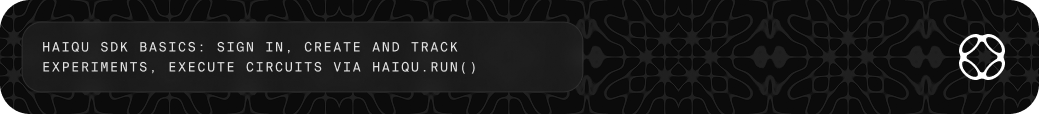

This notebook demonstrates how to use `haiqu.run()` to execute your circuits on quantum hardware or simulators.

- Haiqu SDK currently supports devices available via IBM Quantum and AWS Braket.
- It is also possible to simulate quantum circuits using noisy simulators of some IBM devices and Qiskit Aer simulator

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `haiqu.run()`

- **What does it do?** This function does exactly what you'd expect: it runs your quantum circuits on available quantum hardware or simulators.
- **How do I use it?** Pass a quantum circuit along with necessary parameters (like the device and the number of shots) to `haiqu.run()` to create a run job, then retrieve results with `job.result()`.
- **What are the options?** Optional parameters include `observables`, `parameters`, `options`, and `use_mitigation` for enabling quantum error mitigation.
- **Which option do you recommend?** Start with running single circuits, then explore measuring observables, using parameterized circuits, and enabling error mitigation as needed.

## Initialize the example

Import the necessary libraries, initialize the Haiqu SDK, and create an adder circuit to demonstrate circuit execution. The adder circuit adds two integers m and k.

**Important:** To work with the Haiqu SDK, you need a Haiqu API key (get one at [haiqu.ai](https://haiqu.ai)). Once you have obtained a Haiqu API key, it should be stored in the `HAIQU_API_KEY` environment variable, or passed to the `haiqu_api_access` kwarg to the `haiqu.login()` function. After successful authentication, initialize a Haiqu experiment using `haiqu.init("Experiment Name")`. For more information, refer to the [Haiqu Quickstart Guide](https://docs.haiqu.ai/quickstart/qs_local).

In [1]:
from qiskit.visualization import plot_histogram
from haiqu.sdk import haiqu, set_haiqu_mpl_style

haiqu.login()
haiqu.init("Haiqu Run Tutorial")
set_haiqu_mpl_style()

### Define a circuit

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate
import numpy as np

def build_adder_circuit(num_qubits, m, k):
    """
    Builds a quantum circuit that adds integer k to m using the QFT.

    Parameters:
    - num_qubits (int): Number of qubits.
    - m (int): Initial value.
    - k (int): Value to add.

    Returns:
    - QuantumCircuit implementing |m⟩ -> |m + k⟩ with measurement.
    - Binary strings for m and m+k (for verification).
    """
    m_binary = f"{m:0{num_qubits}b}"
    m_plus_k_binary = f"{m + k:0{num_qubits}b}"
    adder = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        if m_binary[i] == "1":
            adder.x(num_qubits - 1 - i)
    adder.compose(QFTGate(num_qubits), inplace=True)
    for i in range(num_qubits):
        adder.rz(k * np.pi / 2**i, num_qubits - i - 1)
    adder.compose(QFTGate(num_qubits).inverse(), inplace=True)
    adder.measure_all()
    return adder, m_binary, m_plus_k_binary

adder, m_binary, m_plus_k_binary = build_adder_circuit(num_qubits=10, m=343, k=19)
haiqu.draw(adder)

## Execute the quantum circuit

First, we will list available devices, then run the adder circuit on a selected device using `haiqu.run()`. Finally, we will retrieve and display the results.

### Select a device

To list all available QPU devices use `haiqu.list_devices()`. To view available simulators, use `haiqu.list_simulators()`.

**Note:** By default, all haiqu list methods render results in a dedicated widget and return `None`. To return a list of job handles, use `widget=False`. To return as a pandas dataframe, use `pandas=True`. See the [Haiqu SDK Reference / Core platform functions](https://docs.haiqu.ai/reference/core/list) for more information.

In [3]:
haiqu.list_devices() # to list simulators, use haiqu.list_simulators()

Vendor,Quantum System,Qubits,Status,Queue Length
AWS,aws_iqm_emerald,54,online,0
AWS,aws_ionq_forte_1,36,offline,0
AWS,aws_ionq_aria_1,25,retired,0
AWS,aws_iqm_garnet,20,online,0
IBM,ibm_aachen,156,online,0
IBM,ibm_pittsburgh,156,online,0
IBM,ibm_kingston,156,online,4
IBM,ibm_marrakesh,156,online,11
IBM,ibm_fez,156,online,0
IBM,ibm_boston,156,online,55


To run on a particular quantum device, we need to specify our credentials in the `options` parameter of the `haiqu.run()` function. We will use `fake_fez` as a device for demonstration purposes, but you can replace it with the real `ibm_fez` from the list obtained earlier, as long as you have access to it.

In [4]:
device_id = "fake_fez"
options = {}

# Uncomment the following lines to run on the actual IBM Quantum device
# device_id = "ibm_fez"  

# options = {
#     "ibm_quantum_token": "YOUR_IBM_QUANTUM_TOKEN",  # Replace with your IBM Quantum API key
#     "ibm_quantum_instance": "YOUR_IBM_QUANTUM_INSTANCE_ID",  # Replace with your IBM Quantum instance CRN ID if needed
# }

### Estimate QPU Cost

It can be useful to know how expensive running the circuit on the device is expected to be prior to running it. To get an estimate, we can set `dry_run=True` when calling `haiqu.run()`. This will make it stop before sending any jobs to the quantum device or simulator.

In [5]:
dry_job = haiqu.run(
    adder,
    device_id=device_id,
    shots=1024,
    options=options,
    dry_run=True,
)

In [6]:
dry_job.retrieve_status()

<JobStatus.INITIALIZING: 'Initializing'>

In [7]:
haiqu.list_jobs(pandas=True)

,id,name,description,user_id,experiment_id,status,job_type,device_id,creation_date,run_date,finish_date,logs,quality,info,time,parameters
0,jb-c4fda8c4-656d-41c3-9711-7aa6d95d9eac,run-job-circuit-46,None,69,exp-42cd0113-82b8-486f-9edd-3508dc827674,JobStatus.INITIALIZING,JobType.RUN,fake_fez,2026-05-28 13:48:01.944293,None,None,Initializing the job...,None,{},None,None


Use `haiqu.estimated_qpu_cost` property to retieve as estimate

In [8]:
dry_job.result() # blocking call
for label, estimate in dry_job.estimated_qpu_cost.items():
    print(f'{label:9s}  {estimate["amount"]:.2f} {estimate["unit"]}')

native     2.28 s
converted  0.00 USD


The "native" amount is expressed in the units of the device provider. For example, IBM uses seconds. The "converted" amount is an approximate conversion of the native amount to dollars.

**Note:** for a simulator device, the converted estimated QPU cost will always be zero, since no QPU execution is involved in simulation.

### Submit a Job

If we're satisfied that this cost is acceptable, we can submit the actual job to run the circuit.

In [9]:
# Submit job and save job ID
job = haiqu.run(
    adder,
    device_id=device_id,
    shots=1024,
    options=options,
)
saved_job_id = job.id
print(f"Job ID: {saved_job_id}")

Job ID: jb-658577de-d1ca-4c30-aef3-eff98ad465b0


### Retrieve Job by ID

A `RunJobModel` object, which is a handle for a job regardless of it's status, is uniquely defined by it's job ID and can be constructed from it using `haiqu.get_job(job_id)`. It is a common practive to save the Job ID string and later use it to retreive to check the status or get results:

| Action | Code |
|---|---|
| Create job handle | `haiqu.get_job(job_id)` |
| Check current status | `haiqu.get_job(job_id).retrieve_status()` |
| Retrieve results | `haiqu.get_job(job_id).result()` *(blocking)* |

In [10]:
# Retrieve result from saved job ID
job = haiqu.get_job(saved_job_id)

### Track Jobs

You can use `haiqu.list_jobs()` to fetch infomation about your jobs. This will render a list of all your jobs for an experiment, as well as their current status, name, description, and some additional information. By default, jobs for the current experiment are returned. However, it it possble to specify an experiment using `experiment_id` kwarg.

Most common uses include

| Action | Code | Returns |
|---|---|---|
| Render the list of jobs for current experiment | `haiqu.list_jobs()` | `None` *(renders an HTML widget)* |
| Return list of job objects | `haiqu.list_jobs(widget=False)` | `List[JobModel]` |
| Return pandas dataframe with jobs  | `haiqu.list_jobs(pandas=True)` | `pandas.DataFrame` |

In [11]:
haiqu.list_jobs(pandas=True)

,id,name,description,user_id,experiment_id,status,job_type,device_id,creation_date,run_date,finish_date,logs,quality,info,time,parameters
0,jb-658577de-d1ca-4c30-aef3-eff98ad465b0,run-job-circuit-46,None,69,exp-42cd0113-82b8-486f-9edd-3508dc827674,JobStatus.INITIALIZING,JobType.RUN,fake_fez,2026-05-28 13:48:13.957303,None,NaT,Initializing the job...,None,{},NaN,None
1,jb-c4fda8c4-656d-41c3-9711-7aa6d95d9eac,run-job-circuit-46,None,69,exp-42cd0113-82b8-486f-9edd-3508dc827674,JobStatus.DONE,JobType.RUN,fake_fez,2026-05-28 13:48:01.944293,None,2026-05-28 13:48:09.679393,Initializing the job...\nThe pipeline is ready...,None,{},0.0,None


### Retrieve Results
Run this cell to get results once the job is complete. For real QPU jobs, this may take minutes to hours. You can close the notebook and come back later—just use the saved job ID to retrieve results in a new session.

A cheatsheet of useful methods and properties of a `JobModel`:

| Action | Code | Note
|---|---|---|
| Check current status | `job.retrieve_status()` | |
| Retrieve results | `job.result()` *(blocking)* | Returns `None` if `dry_run=True` |
| Print auto-refreshable log | `job.progress()` *(blocking)* | Displays up-to-date logs in an HTML widget and blocks|

**Note:** `job.result()` and `job.progress()` are blocking calls. If the job is not complete, the function will not return until results are ready.

In [12]:
print(f"Job status before job.result(): {job.retrieve_status()}")
result = job.result()
print(f"Job status after job.result(): {job.retrieve_status()}")

Job status before job.result(): JobStatus.INITIALIZING
Job status after job.result(): JobStatus.DONE


You can visualize the outcome using `plot_histogram` function or apply your own visualization techniques.

Haiqu supports logging objects inside an experiment to [Haiqu dashboard](https://dashboard.haiqu.ai) by wrapping that object in `haiqu.log()` call. This could be a circuit, a plot or any other object you wish to appear on a dashboard. For more information, refer to [Haiqu SDK Reference / Log Objects](https://docs.haiqu.ai/reference/core/log).

Expected result is 0101101010
Probability of measuring the correct result: 0.2490
Logged object to the experiment 'Haiqu Run Tutorial'. You can see logged data on Dashboard: https://dashboard.haiqu.ai


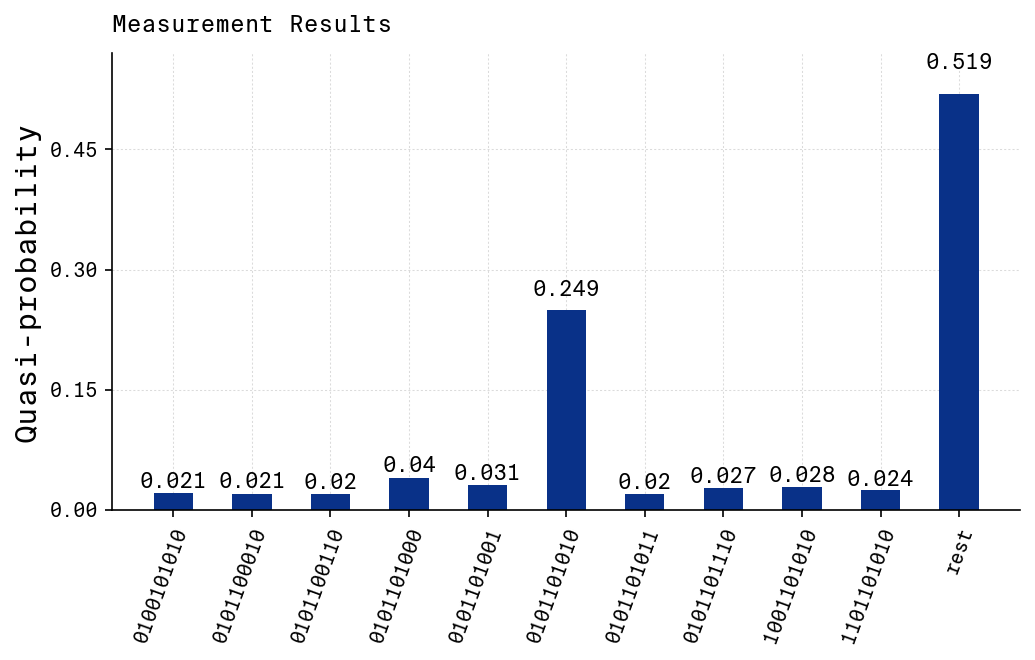

In [13]:
print(f"Expected result is {m_plus_k_binary}")
print(f"Probability of measuring the correct result: {result[0].get(m_plus_k_binary, 0):.4f}")

fig = plot_histogram(result[0], title="Measurement Results", number_to_keep=10)
# Note that haiqu.log wraps the figure returned
print(haiqu.log(fig, name="My Plot", description="My Description"))
# Display the figure
fig

> **💡 Good to Know:** Instead of using `device_id` it is possible to pass a `device` parameter, for instance if you already have a device object from `haiqu.get_device()`.

### That's it!

Now you know the very basics of the `haiqu.run()`, as well as how to define, run, track and retrieve results from jobs. Take a look at other notebooks in this directory, such as `haiqu_run_use_mitigation`, `haiqu_run_use_mitigation_options`, `haiqu_run_quality_estimates` and `haiqu_run_uncertainty_estimate`, as well as other SDK Reference notebooks to see how Haiqu SDK can be used to achieve superior results. Also, consider the application demo notebooks, which show how the Haiqu SDK helps to get an advantage when solving real problems.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

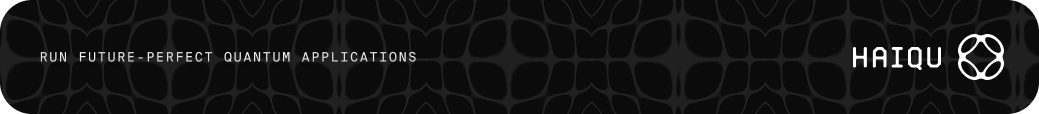